<a href="https://colab.research.google.com/github/bookwork123/MachineLearning/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [36]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Task 1: Load the dataset into a Pandas DataFrame.

In [2]:
churn = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

Task 2: Use structural inspection methods (head(), info(), describe()) to analyze features such as tenure, MonthlyCharges, TotalCharges, Contract, and PaymentMethod.

In [8]:
churn.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
churn.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Task 3: Drop any non-informative identifiers (such as customerID).

In [9]:
churn = churn.drop(['customerID'], axis=1)
# Every other column seemed informative to some extent

Task 4: Quantify any missing or implicit missing values across the columns (handling whitespace strings in TotalCharges) and implement a structured imputation strategy using Scikit-Learn's SimpleImputer.

In [10]:
churn.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [22]:
totalCharges = churn['TotalCharges']
sum(totalCharges == ' ')
# there are 11 values in TotalCharges that contain only whitespace

11

In [24]:
churn['TotalCharges'] = pd.to_numeric(churn['TotalCharges'], errors='coerce') # convert TotalCharges to numeric
imputer = SimpleImputer(strategy='median') # create SciKit SimpleImputer using median
churn['TotalCharges'] = imputer.fit_transform(churn[['TotalCharges']]) # impute the missing values to the median

print("Missing values in TotalCharges:", churn['TotalCharges'].isnull().sum()) # check for any more missing values
print("Data type of TotalCharges:", churn['TotalCharges'].dtype) # check data type (float64)

Missing values in TotalCharges: 0
Data type of TotalCharges: float64


Task 5: Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (StandardScaler or MinMaxScaler) to numerical columns and encoding (OneHotEncoder) to categorical columns.

In [28]:
num_attributes = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
cat_attributes = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                  'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                  'PaperlessBilling', 'PaymentMethod']

transformation = ColumnTransformer([
    ("num", StandardScaler(), num_attributes),
    ("cat", OneHotEncoder(), cat_attributes),
])

pipeline = Pipeline([
    ("transformation", transformation),
])

# Fit and transform the features
churn_prepared = pipeline.fit_transform(churn)

Task 6: Append an SGDClassifier configured with loss='log_loss' to the end of your pipeline to perform logistic regression and enable probability estimation.

In [38]:
pipeline = Pipeline([
    ("transformation", transformation),
    ('classifier', SGDClassifier(loss='log_loss', random_state=42))
])

Task 7: Split your dataset into training and test sets using 3 different train/test split ratios (for example, 80/20, 70/30, and 60/40), fit your complete pipeline on each configuration, and evaluate performance using a confusion matrix, classification report, and ROC-AUC curve. Report on any performance differences detected across the various splitting ratios.



In [39]:
X = churn.drop(columns=['Churn'])
y = churn['Churn']

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_60, X_test_60, y_train_60, y_test_60 = train_test_split(X, y, test_size=0.4, random_state=42)

print("Pipeline constructed successfully.")
print(f"80/20 Training features shape: {X_train_80.shape}")
print(f"80/20 Testing features shape: {X_test_80.shape}")
print()
print(f"70/30 Training features shape: {X_train_70.shape}")
print(f"70/30 Testing features shape: {X_test_70.shape}")
print()
print(f"60/40 Training features shape: {X_train_60.shape}")
print(f"60/40 Testing features shape: {X_test_60.shape}")

Pipeline constructed successfully.
80/20 Training features shape: (5634, 19)
80/20 Testing features shape: (1409, 19)

70/30 Training features shape: (4930, 19)
70/30 Testing features shape: (2113, 19)

60/40 Training features shape: (4225, 19)
60/40 Testing features shape: (2818, 19)


Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1036
         Yes       0.66      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.80      0.81      0.81      1409



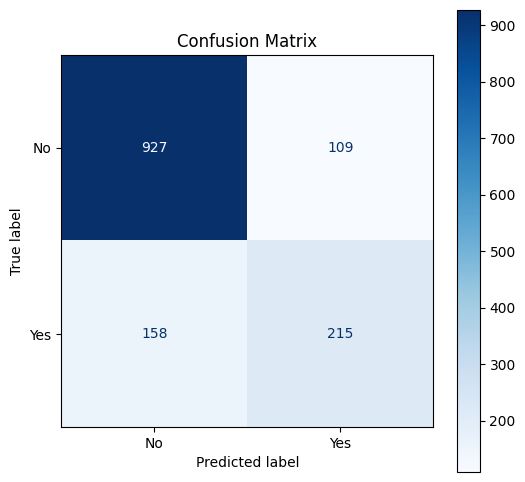

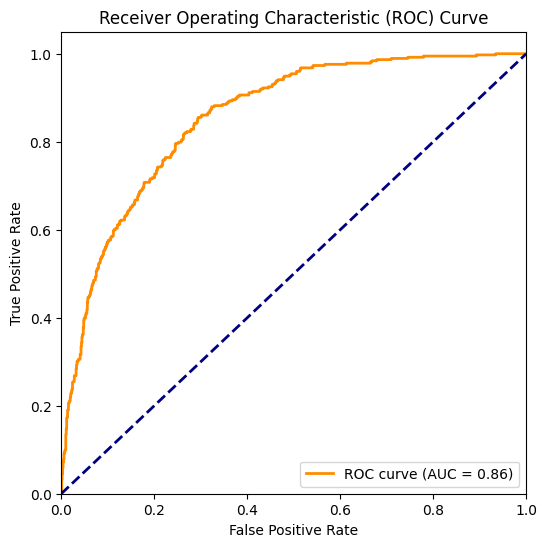

In [41]:
#80/20 split
# Fit the entire pipeline on the training data
pipeline.fit(X_train_80, y_train_80)

# Generate predictions and probability scores on the test set
y_pred = pipeline.predict(X_test_80)
y_scores = pipeline.predict_proba(X_test_80)[:, 1]

# Print classification report
print("Classification Report:")
print(classification_report(y_test_80, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test_80, y_test_80, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC Curve and ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test_80, y_scores, pos_label='Yes')
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Classification Report:
              precision    recall  f1-score   support

          No       0.79      0.96      0.87      1539
         Yes       0.74      0.32      0.45       574

    accuracy                           0.78      2113
   macro avg       0.76      0.64      0.66      2113
weighted avg       0.78      0.78      0.75      2113



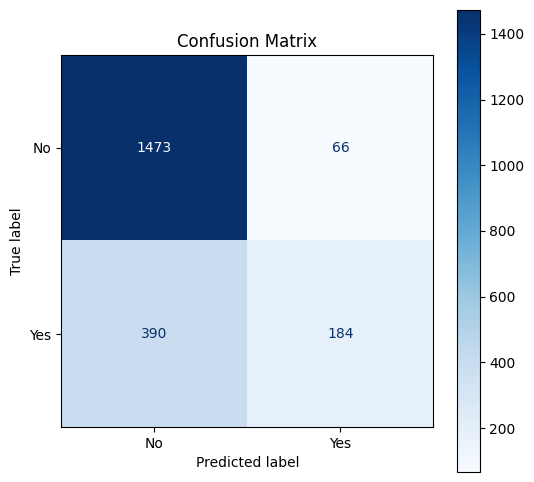

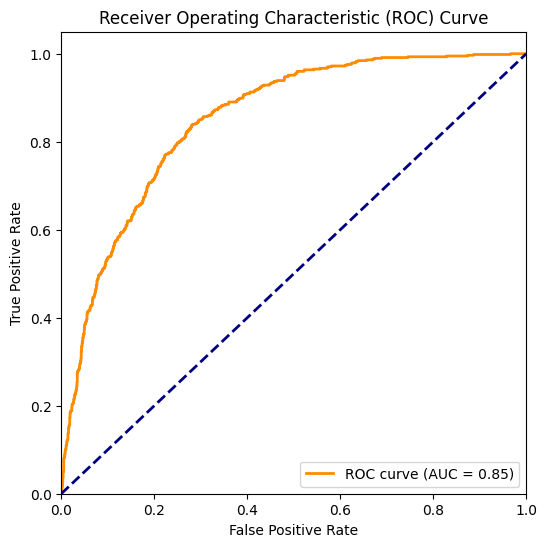

In [42]:
#70/30 split
# Fit the entire pipeline on the training data
pipeline.fit(X_train_70, y_train_70)

# Generate predictions and probability scores on the test set
y_pred = pipeline.predict(X_test_70)
y_scores = pipeline.predict_proba(X_test_70)[:, 1]

# Print classification report
print("Classification Report:")
print(classification_report(y_test_70, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test_70, y_test_70, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC Curve and ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test_70, y_scores, pos_label='Yes')
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Classification Report:
              precision    recall  f1-score   support

          No       0.89      0.82      0.86      2069
         Yes       0.60      0.72      0.65       749

    accuracy                           0.80      2818
   macro avg       0.74      0.77      0.76      2818
weighted avg       0.81      0.80      0.80      2818



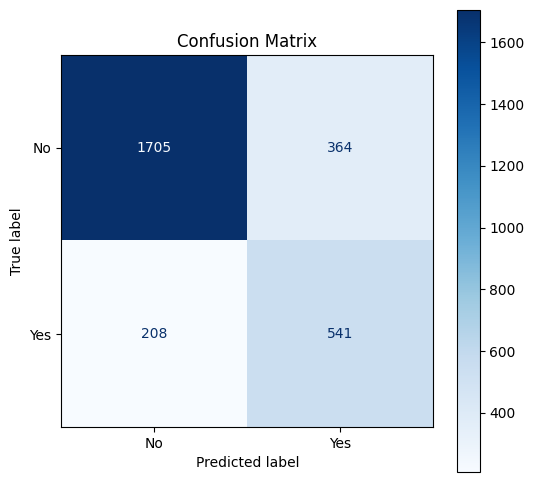

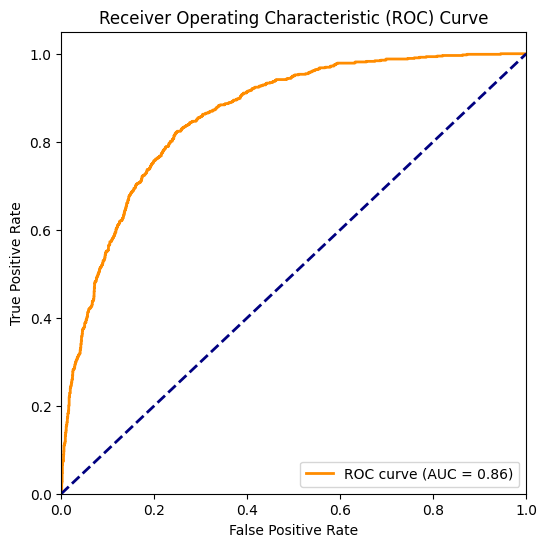

In [43]:
#60/40 split
# Fit the entire pipeline on the training data
pipeline.fit(X_train_60, y_train_60)

# Generate predictions and probability scores on the test set
y_pred = pipeline.predict(X_test_60)
y_scores = pipeline.predict_proba(X_test_60)[:, 1]

# Print classification report
print("Classification Report:")
print(classification_report(y_test_60, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test_60, y_test_60, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC Curve and ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test_60, y_scores, pos_label='Yes')
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Performance Differences:


*   The 60/40 model had the highest precision when predicting a 'No' (a customer who didn't churn) at 89%. It's accuracy when predicting a 'Yes' was only 60%, though, which was the lowest accuracy when predicting a 'Yes.'
*   All models had a similar AUC between 0.85 and 0.86, as well as a similar ROC curve.
*   The confusion matrix shows similar proportional results.



Task 8: Generate a 2D decision boundary visualization or inspect model feature coefficients to interpret how the model separates churning customers from retained customers.



In [46]:
# Extract feature names from the preprocessor step
cat_encoder = pipeline.named_steps['transformation'].named_transformers_['cat']
encoded_cat_features = cat_encoder.get_feature_names_out(cat_attributes).tolist()

# Combine numerical and encoded categorical feature names
all_feature_names = num_attributes + encoded_cat_features

# Retrieve coefficients from the SGDClassifier step
coefficients = pipeline.named_steps['classifier'].coef_[0]

# Create a DataFrame to view feature importance
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Display top features pushing toward Churn and Retained
print("Top features pushing toward Churn:")
print(feature_importance_df.head(10))

print("\nTop features pushing toward Retention (No Churn):")
print(feature_importance_df.tail(10))

Top features pushing toward Churn:
                        Feature  Coefficient
16  InternetService_Fiber optic     1.202033
36      Contract_Month-to-month     0.995650
32              StreamingTV_Yes     0.691809
6                    Partner_No     0.683116
3                  TotalCharges     0.669883
11             PhoneService_Yes     0.635057
40         PaperlessBilling_Yes     0.628975
35          StreamingMovies_Yes     0.610533
8                 Dependents_No     0.570043
26         DeviceProtection_Yes     0.554969

Top features pushing toward Retention (No Churn):
                                 Feature  Coefficient
22      OnlineBackup_No internet service     0.067625
17                    InternetService_No     0.067625
34   StreamingMovies_No internet service     0.067625
31       StreamingTV_No internet service     0.067625
25  DeviceProtection_No internet service     0.067625
0                          SeniorCitizen    -0.007899
15                   InternetService_DSL 